# IN5437 — Assignment 1
## Question 5: Gaussian Filtering

**Name:** Benjamine  
**Index:** 258762A

- (a) Compute a normalized 5×5 Gaussian kernel for σ = 2 using NumPy.
- (b) Visualize a 51×51 Gaussian kernel as a 3D surface plot.
- (c) Apply Gaussian smoothing manually using the computed kernel.
- (d) Apply Gaussian smoothing using OpenCV's `cv.GaussianBlur()`.

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

### Question 05.a: 5×5 Gaussian kernel for σ = 2

In [2]:
sigma = 2
size = 5

# Create coordinates from -2 to +2 (centered on 0)
x = np.arange(-2, 3)    # [-2, -1, 0, 1, 2]
y = np.arange(-2, 3)    # [-2, -1, 0, 1, 2]
xx, yy = np.meshgrid(x, y)

# Apply the Gaussian formula
kernel_5 = (1 / (2 * np.pi * sigma**2)) * np.exp(-(xx**2 + yy**2) / (2 * sigma**2))

# Normalize so values sum to 1
kernel_5 = kernel_5 / kernel_5.sum()

print('5×5 Gaussian kernel (σ = 2):')
print(np.round(kernel_5, 4))
print(f'Sum = {kernel_5.sum():.4f}')

5×5 Gaussian kernel (σ = 2):
[[0.0232 0.0338 0.0383 0.0338 0.0232]
 [0.0338 0.0492 0.0558 0.0492 0.0338]
 [0.0383 0.0558 0.0632 0.0558 0.0383]
 [0.0338 0.0492 0.0558 0.0492 0.0338]
 [0.0232 0.0338 0.0383 0.0338 0.0232]]
Sum = 1.0000


### Question 05.b: 51×51 Gaussian kernel — 3D surface plot

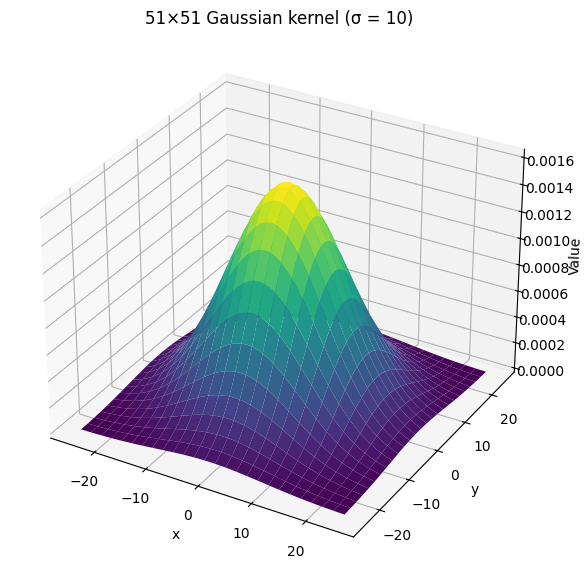

In [3]:
sigma = 10
size = 51

# Coordinates from -25 to +25
x = np.arange(-25, 26)
y = np.arange(-25, 26)
xx, yy = np.meshgrid(x, y)

# Gaussian formula
kernel_51 = (1 / (2 * np.pi * sigma**2)) * np.exp(-(xx**2 + yy**2) / (2 * sigma**2))
kernel_51 = kernel_51 / kernel_51.sum()

# 3D surface plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(xx, yy, kernel_51, cmap='viridis')
ax.set_title('51×51 Gaussian kernel (σ = 10)')
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('Value')
plt.show()

### Question 05.c: Apply the manual kernel to an image

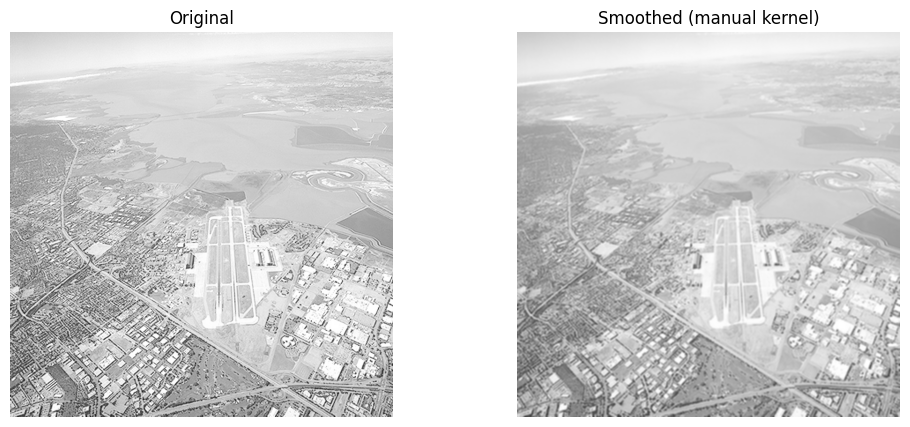

In [4]:
q5_im = cv.imread('../images/runway.png', cv.IMREAD_GRAYSCALE)
assert q5_im is not None, "File could not be read. Check the path."

# Apply our manually built 5×5 kernel using filter2D
g_5c = cv.filter2D(q5_im, -1, kernel_5)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].imshow(q5_im, cmap='gray', vmin=0, vmax=255); ax[0].set_title('Original'); ax[0].axis('off')
ax[1].imshow(g_5c,  cmap='gray', vmin=0, vmax=255); ax[1].set_title('Smoothed (manual kernel)'); ax[1].axis('off')
plt.show()

### Question 05.d: Apply OpenCV's cv.GaussianBlur()

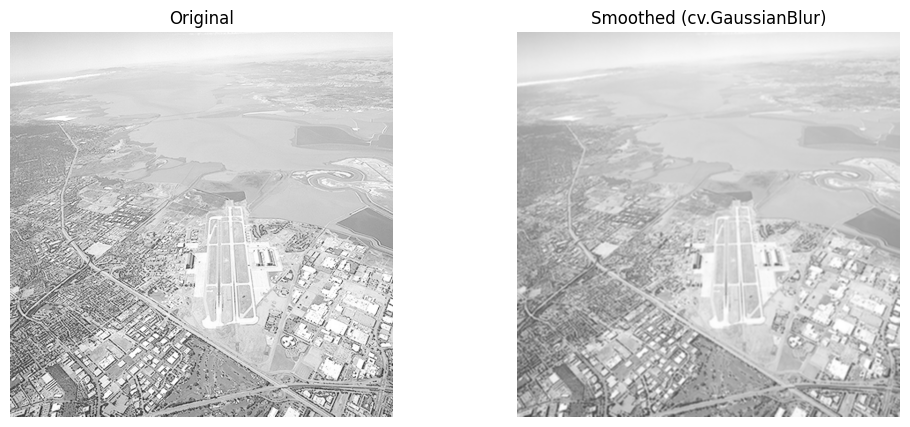

In [5]:
g_5d = cv.GaussianBlur(q5_im, (5, 5), 2)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].imshow(q5_im, cmap='gray', vmin=0, vmax=255); ax[0].set_title('Original'); ax[0].axis('off')
ax[1].imshow(g_5d,  cmap='gray', vmin=0, vmax=255); ax[1].set_title('Smoothed (cv.GaussianBlur)'); ax[1].axis('off')
plt.show()